# AgriPrice-IQ: Exploratory Data Analysis (EDA)
This notebook performs exploratory data analysis on the clean Canadian retail food price dataset (Jan 2021 – Jul 2026) extracted directly from our SQLite database. 

### Objectives:
1. Analyze national inflation and retail price trends over time.
2. Compare price trajectories across the 7 core commercial categories.
3. Investigate provincial price dispersions (with a focus on British Columbia).
4. Identify high-volatility food commodities using the Coefficient of Variation.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


In [19]:
# Connect to SQLite database
conn = sqlite3.connect('../database/agriprice_iq.db')

# Query the clean retail prices table
query = "SELECT * FROM retail_prices;"
df = pd.read_sql(query, conn)
conn.close()

# Parse reference date as datetime
df['date'] = pd.to_datetime(df['date'])

print(f"Successfully loaded dataset from SQLite! Shape: {df.shape}")
display(df.head())

Successfully loaded dataset from SQLite! Shape: (74369, 6)


,product_name,province,date_raw,price,date,category
0,"Beef stewing cuts, per kilogram 5",British Columbia,January 2021,15.22,2021-01-01,Meat & Poultry
1,"Beef striploin cuts, per kilogram 5",British Columbia,January 2021,25.58,2021-01-01,Meat & Poultry
2,"Beef top sirloin cuts, per kilogram 5",British Columbia,January 2021,17.49,2021-01-01,Meat & Poultry
3,"Beef rib cuts, per kilogram 5",British Columbia,January 2021,25.46,2021-01-01,Meat & Poultry
4,"Ground beef, per kilogram 5",British Columbia,January 2021,9.75,2021-01-01,Meat & Poultry


## 1. National Retail Price Trends (2021–2026)
We track the overall average monthly retail price across Canada to understand macro-level inflation patterns over the 5+ year timeline.

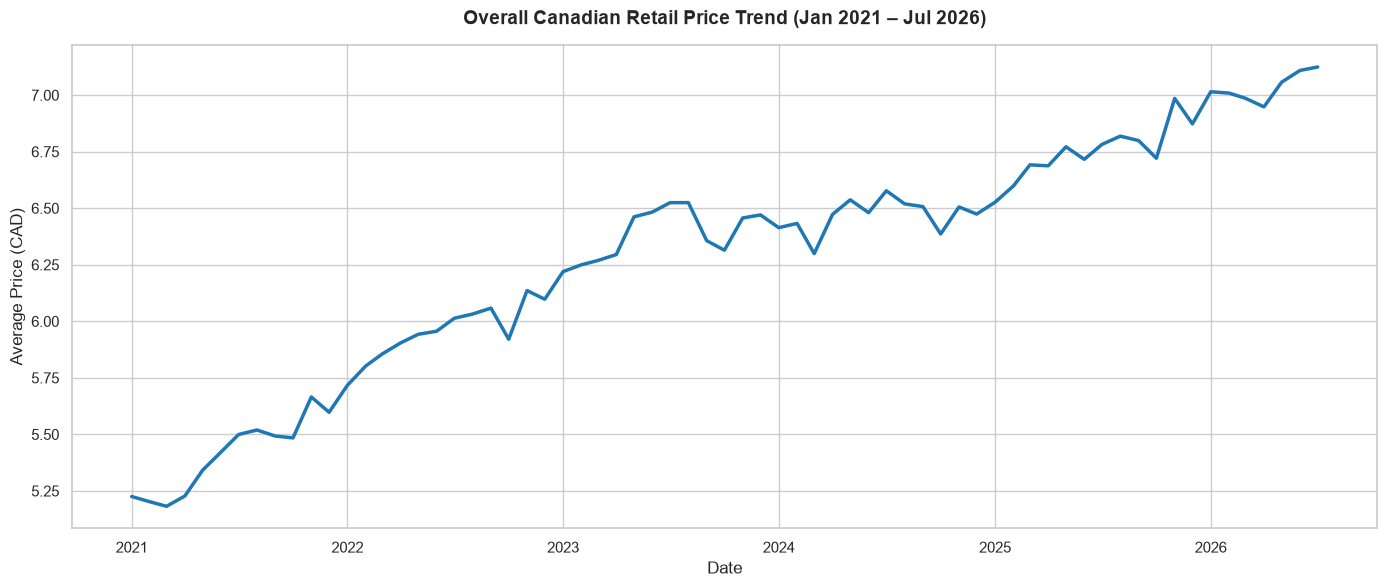

In [20]:
national_trend = df.groupby('date')['price'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=national_trend, 
    x='date', 
    y='price', 
    color='#1f77b4', 
    linewidth=2.5
)

plt.title('Overall Canadian Retail Price Trend (Jan 2021 – Jul 2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Price (CAD)', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Category-Level Price Trajectories
Next, we evaluate how prices have diverged across our 7 standardized commercial categories (*Dairy & Eggs, Meat & Poultry, Fresh Produce, Bakery & Grains, Pantry Staples, Beverages, Personal Care & Household*).

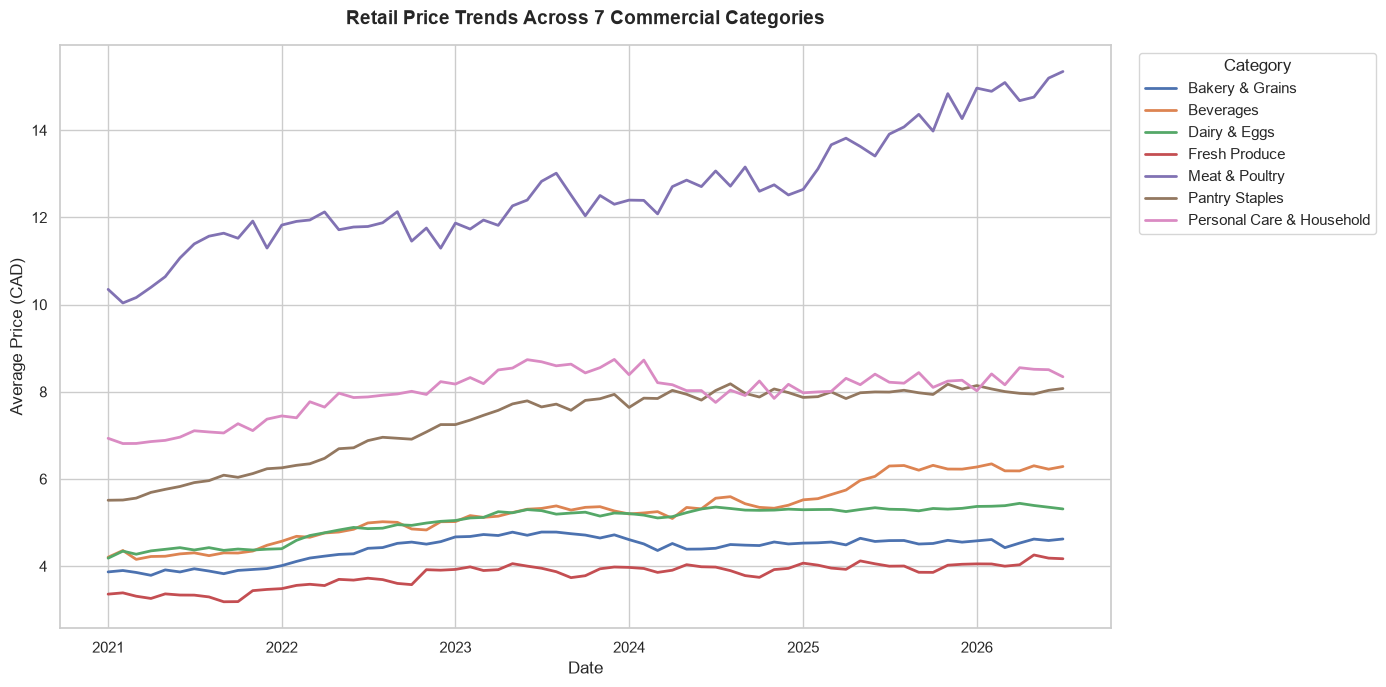

In [21]:
category_trend = df.groupby(['date', 'category'])['price'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=category_trend, 
    x='date', 
    y='price', 
    hue='category', 
    linewidth=2
)

plt.title('Retail Price Trends Across 7 Commercial Categories', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Price (CAD)', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Category')
plt.tight_layout()
plt.show()

## 3. Provincial Price Disparities & Regional Comparison
We examine average retail prices across the 10 Canadian provinces to uncover geographical cost variations.

/var/folders/zv/ljgjz5z10y93dzq0hqkt_5zh0000gn/T/ipykernel_7642/1086774746.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


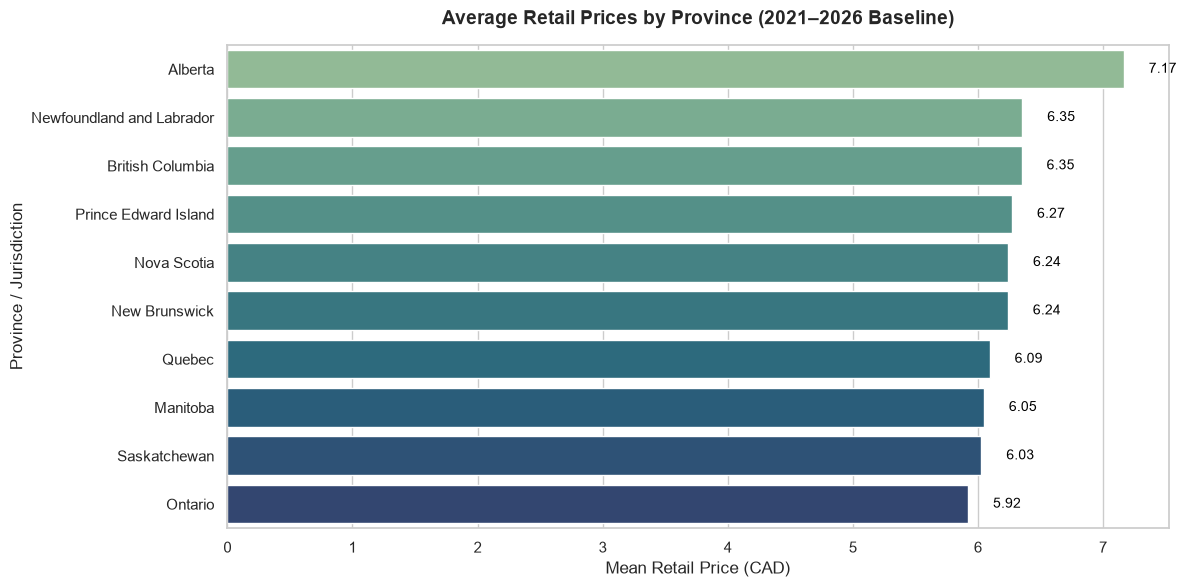

In [22]:
provincial_avg = df.groupby('province')['price'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=provincial_avg, 
    x='price', 
    y='province', 
    palette='crest'
)

plt.title('Average Retail Prices by Province (2021–2026 Baseline)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mean Retail Price (CAD)', fontsize=12)
plt.ylabel('Province / Jurisdiction', fontsize=12)

# Annotate values on bars
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.2, p.get_y() + p.get_height()/2., f'{width:.2f}', 
            ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

## 4. Commodity Price Volatility (Coefficient of Variation)
To identify which specific items fluctuate the most, we compute the Coefficient of Variation ($\sigma / \mu$) for each individual commodity product over time.

Top 10 Most Volatile Food Commodities:


,category,product_name,mean,std,volatility_cv
99,Pantry Staples,"Olive oil, 1 litre 6",12.050493,3.005861,0.249439
75,Meat & Poultry,"Beef top sirloin cuts, per kilogram 5",22.633080,5.371236,0.237318
64,Fresh Produce,"Romaine lettuce, unit 5",3.359030,0.781963,0.232794
62,Fresh Produce,"Potatoes, 4.54 kilograms 5",5.894701,1.369529,0.232332
74,Meat & Poultry,"Beef striploin cuts, per kilogram 5",28.811588,6.234065,0.216374
94,Pantry Staples,"Canola oil, 3 litres 6",11.484328,2.398132,0.208818
68,Fresh Produce,"Strawberries, 454 grams 6",4.780806,0.981770,0.205357
85,Meat & Poultry,"Pork shoulder cuts, per kilogram 5",7.682931,1.553212,0.202164
12,Beverages,"Roasted or ground coffee, 340 grams 6",7.076567,1.413085,0.199685
97,Pantry Staples,"Infant formula, 900 grams 6",39.660716,7.822061,0.197224


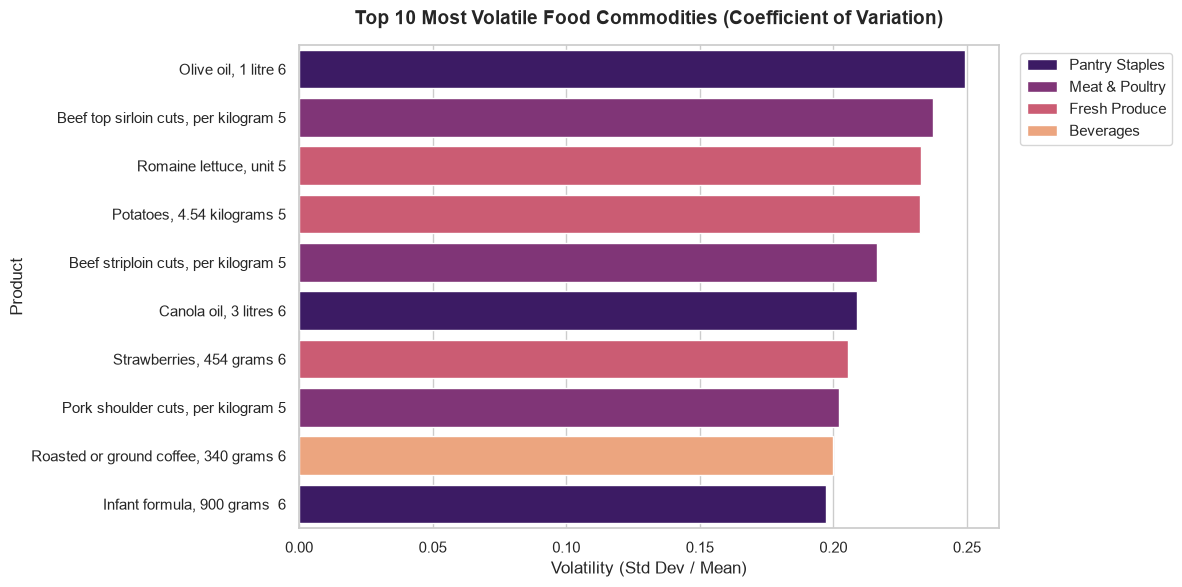

In [24]:
volatility_df = df.groupby(['category', 'product_name'])['price'].agg(['mean', 'std']).reset_index()
volatility_df['volatility_cv'] = volatility_df['std'] / volatility_df['mean']
volatility_df = volatility_df.sort_values(by='volatility_cv', ascending=False)

print("Top 10 Most Volatile Food Commodities:")
display(volatility_df.head(10))

# Visualize top volatile commodities
plt.figure(figsize=(12, 6))
top_volatile = volatility_df.head(10)
sns.barplot(data=top_volatile, x='volatility_cv', y='product_name', hue='category', dodge=False, palette='magma')
plt.title('Top 10 Most Volatile Food Commodities (Coefficient of Variation)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Volatility (Std Dev / Mean)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Conclusion & Key Takeaways
Through this exploratory data analysis of Canadian retail food prices (Jan 2021 – Jul 2026), several key macroeconomic and regional insights were uncovered:

* **Sustained National Inflation:** Canadian retail food prices experienced a steady upward trajectory, climbing from a national average baseline of ~$5.20 CAD in early 2021 to over ~$7.00 CAD by mid-2026.
* **Category Cost Divergence:** **Meat & Poultry** commands the highest absolute retail prices (ranging between $12–$15 CAD), whereas **Fresh Produce** and **Bakery & Grains** remain lower in nominal cost but exhibit higher sensitivity.
* **Regional Disparities:** **Alberta** records the highest average retail food prices ($7.17 CAD), while **British Columbia** and **Newfoundland and Labrador** sit closely behind at $6.35 CAD, reinforcing the need for localized provincial modeling.
* **High-Volatility Commodities:** Staple items like **Olive oil**, **Beef cuts**, and **Romaine lettuce** display the highest Coefficient of Variation, highlighting vulnerable supply chain nodes that will serve as critical predictive targets in our modeling phase.